# Thesis Results

**Cross-Species Fruit Quality Grading via Few-Shot Prototypical Networks**
Amr Samir - Master's Thesis, 2026

---

This notebook **computes nothing**. It loads the finished runs produced by
`scripts/reproduce_thesis.py` and renders them. Re-run it any time another seed
or variant completes; it takes seconds.

Every table below is followed by the `metrics.json` key path its numbers came
from, so each figure quoted in the thesis is traceable to a file and a key.

Two reading notes carried over from `RUNBOOK.md`:

- **The two confidence intervals mean different things.** `ci_95_episode` is a
  t-interval over pooled per-episode accuracies (n = trials x episodes);
  `ci_95_trial` is over the trial means (n = trials, usually 5) and is much
  narrower because averaging 600 episodes first removes most of the variance.
  The thesis should quote the **episode-level** one, because that is what every
  baseline and ablation table reports. They are shown side by side here so they
  can never be conflated again.
- **Baselines are reported as measured, including where they beat this method.**
  The significance test is two-sided; an earlier one-sided version returned
  p = 1.00 for baselines that outperformed, which read as "no difference".

In [1]:
import json, os, sys, pathlib, warnings
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

REPO_ROOT = pathlib.Path(os.path.abspath(os.path.join(os.getcwd(), '..')))
RESULTS   = REPO_ROOT / 'results'


def load_runs():
    # Every non-smoke run directory that has a metrics.json, newest last.
    out = []
    for d in sorted(RESULTS.glob('run_*')):
        if 'smoke' in d.name:
            continue
        f = d / 'metrics.json'
        if not f.is_file():
            continue
        try:
            out.append((d, json.loads(f.read_text(encoding='utf-8'))))
        except Exception as e:
            print(f'  ! could not read {d.name}: {e}')
    return out


def variant_of(m):
    # Human label for a run's configuration.
    mo = m.get('model', {})
    bits = []
    if m.get('validation', {}).get('protocol') == 'loso':
        bits.append('loso')
    if mo.get('norm_layer', 'batchnorm') != 'batchnorm':
        bits.append(mo['norm_layer'])
    if mo.get('freeze_mode', 'stem_layer1') != 'stem_layer1':
        bits.append(mo['freeze_mode'])
    if mo.get('freeze_bn_stats'):
        bits.append('bnfrozen')
    return '+'.join(bits) if bits else 'baseline'


def key(path):
    # Render the metrics.json key path a table came from.
    display(Markdown(f'<sub>source: `metrics.json` &rarr; `{path}`</sub>'))


def pct(x, nd=2):
    return '-' if x is None else f'{x * 100:.{nd}f}'


def sort_pct(df, col, ascending=False):
    # pct() returns strings, so sort_values would order them lexicographically
    # ('8.33' > '95.83'). Sort on a numeric shadow column instead.
    if col not in df:
        return df
    order = pd.to_numeric(df[col], errors='coerce')
    return df.assign(_k=order).sort_values('_k', ascending=ascending).drop(columns='_k')


RUNS = load_runs()
if not RUNS:
    raise SystemExit(
        'No completed runs found under results/.\n'
        'Run:  python scripts/reproduce_thesis.py --seed 42'
    )

BASELINE_RUNS = [(d, m) for d, m in RUNS if variant_of(m) == 'baseline']
VARIANT_RUNS  = [(d, m) for d, m in RUNS if variant_of(m) != 'baseline']

# The primary run: seed 42 in the baseline configuration, newest if repeated.
_seed42 = [(d, m) for d, m in BASELINE_RUNS if m.get('seed') == 42]
PRIMARY_DIR, PRIMARY = (_seed42 or BASELINE_RUNS)[-1]

print(f'{len(RUNS)} run(s) found  ({len(BASELINE_RUNS)} baseline, {len(VARIANT_RUNS)} variant)')
print(f'Primary run: {PRIMARY_DIR.name}')

6 run(s) found  (3 baseline, 3 variant)
Primary run: run_20260906_200503_seed42


## 1 - Run inventory and provenance

What actually exists on disk, with the software versions and dataset hash each
run was produced under.

In [2]:
rows = []
for d, m in RUNS:
    env = {}
    envf = d / 'env.json'
    if envf.is_file():
        env = json.loads(envf.read_text(encoding='utf-8'))
    # torch / gpu / git_commit sit at the TOP level of env.json;
    # env['packages'] holds only the remaining third-party versions.
    rows.append({
        'run': d.name,
        'seed': m.get('seed'),
        'config': variant_of(m),
        'val protocol': m.get('validation', {}).get('protocol'),
        'expensive stages': 'yes' if 'species_cv' in m else 'no',
        'wall clock (h)': round(m.get('wall_clock_seconds', 0) / 3600, 2),
        'torch': env.get('torch'),
        'gpu': env.get('gpu'),
        'git commit': (env.get('git_commit') or '')[:8]
                      + (' (dirty)' if env.get('git_dirty') else ''),
        'trainable params': f"{m.get('model', {}).get('trainable_params', 0):,}",
    })

display(pd.DataFrame(rows).set_index('run'))
key('seed / validation.protocol / wall_clock_seconds / model.trainable_params')

ds = PRIMARY['dataset']
display(Markdown(
    f"**Dataset manifest SHA-256:** `{ds['manifest_sha256']}`  \n"
    f"**Total images:** {ds['total_images']:,}"
))
key('dataset.manifest_sha256, dataset.total_images')

display(Markdown(
    f"**Trainable parameters:** {PRIMARY['model']['trainable_params']:,} "
    f"of {PRIMARY['model']['total_params']:,} total.  \n"
    f"<sub>The pre-fix code reported 6,765,569 trainable. A substring match on "
    f"`('layer1','conv1','bn1')` also caught `layer2.0.conv1`, `layer3.0.bn1` and "
    f"every other block's first conv/norm, freezing ~40.7% more than intended. "
    f"Numbers below are not comparable to any figure produced before that fix.</sub>"
))
key('model.trainable_params, model.total_params')

,seed,config,val protocol,expensive stages,wall clock (h),torch,gpu,git commit,trainable params
run,,,,,,,,,
run_20260906_200503_seed42,42,baseline,seen_holdout,yes,70.56,2.5.1+cu121,NVIDIA RTX A5000 Laptop GPU,779deea2 (dirty),"11,414,017"
run_20260909_183843_seed1337,1337,baseline,seen_holdout,yes,74.21,2.5.1+cu121,NVIDIA RTX A5000 Laptop GPU,779deea2 (dirty),"11,414,017"
run_20260912_205110_seed2024,2024,baseline,seen_holdout,yes,109.07,2.5.1+cu121,NVIDIA RTX A5000 Laptop GPU,d8a8875c (dirty),"11,414,017"
run_20260917_095534_seed42_bnfrozen,42,bnfrozen,seen_holdout,no,25.58,2.5.1+cu121,NVIDIA RTX A5000 Laptop GPU,97ae4a8a (dirty),"11,414,017"
run_20260918_113021_seed42_loso,42,loso,loso,no,28.06,2.5.1+cu121,NVIDIA RTX A5000 Laptop GPU,97ae4a8a (dirty),"11,414,017"
run_20260919_153413_seed42_loso-bnfrozen,42,loso+bnfrozen,loso,no,23.65,2.5.1+cu121,NVIDIA RTX A5000 Laptop GPU,97ae4a8a (dirty),"11,414,017"


<sub>source: `metrics.json` &rarr; `seed / validation.protocol / wall_clock_seconds / model.trainable_params`</sub>

**Dataset manifest SHA-256:** `8354959198214354683c974f8c64b0ef08c8aad92ff13d3db05dd7d058b95ebe`  
**Total images:** 6,978

<sub>source: `metrics.json` &rarr; `dataset.manifest_sha256, dataset.total_images`</sub>

**Trainable parameters:** 11,414,017 of 11,571,521 total.  
<sub>The pre-fix code reported 6,765,569 trainable. A substring match on `('layer1','conv1','bn1')` also caught `layer2.0.conv1`, `layer3.0.bn1` and every other block's first conv/norm, freezing ~40.7% more than intended. Numbers below are not comparable to any figure produced before that fix.</sub>

<sub>source: `metrics.json` &rarr; `model.trainable_params, model.total_params`</sub>

## 2 - Dataset

Train on {apple, banana, grape}; test on {mango, orange}, which the model never
sees during training.

In [3]:
counts = PRIMARY['dataset']['counts']
train_f = PRIMARY['config']['TRAIN_FRUITS']
test_f  = PRIMARY['config']['TEST_FRUITS']

rows = []
for fruit, c in counts.items():
    rows.append({
        'species': fruit,
        'role': 'train (seen)' if fruit in train_f else 'test (unseen)',
        'fresh': c.get('fresh', 0),
        'rotten': c.get('rotten', 0),
        'total': c.get('fresh', 0) + c.get('rotten', 0),
    })
df = pd.DataFrame(rows)
df.loc[len(df)] = {'species': 'TOTAL', 'role': '', 'fresh': df['fresh'].sum(),
                   'rotten': df['rotten'].sum(), 'total': df['total'].sum()}
display(df.set_index('species'))
key('dataset.counts.<species>.<fresh|rotten>')

,role,fresh,rotten,total
species,,,,
apple,train (seen),765,630,1395
banana,train (seen),749,632,1381
grape,train (seen),770,630,1400
mango,test (unseen),763,630,1393
orange,test (unseen),753,656,1409
TOTAL,,3800,3178,6978


<sub>source: `metrics.json` &rarr; `dataset.counts.<species>.<fresh|rotten>`</sub>

## 3 - Headline: accuracy on unseen species

The thesis claim. Trained on apple/banana/grape, evaluated on mango/orange with
no retraining.

`ci_95_episode` is the interval to quote.

In [4]:
cs = PRIMARY['cross_species']
o  = cs['overall']

display(Markdown(
    f"## {o['mean'] * 100:.2f}%  cross-species accuracy\n\n"
    f"| interval | value | n | what it is over |\n"
    f"|---|---|---|---|\n"
    f"| `ci_95_episode` **(quote this)** | +/- {o['ci_95_episode'] * 100:.2f}% | "
    f"{o['n_episodes']} | pooled per-episode accuracies |\n"
    f"| `ci_95_trial` | +/- {o['ci_95_trial'] * 100:.2f}% | {o['n_trials']} | "
    f"trial means |\n"
))
key('cross_species.overall.{mean,ci_95_episode,n_episodes,ci_95_trial,n_trials}')

rows = []
for fruit, r in cs['per_fruit'].items():
    rows.append({
        'unseen species': fruit,
        'accuracy %': pct(r['mean']),
        'ci_95_episode %': pct(r['ci_95_episode']),
        'n episodes': r['n_episodes'],
        'ci_95_trial %': pct(r['ci_95_trial']),
        'n trials': r['n_trials'],
    })
display(pd.DataFrame(rows).set_index('unseen species'))
key('cross_species.per_fruit.<species>.*')

## 88.18%  cross-species accuracy

| interval | value | n | what it is over |
|---|---|---|---|
| `ci_95_episode` **(quote this)** | +/- 0.21% | 3000 | pooled per-episode accuracies |
| `ci_95_trial` | +/- 0.39% | 5 | trial means |


<sub>source: `metrics.json` &rarr; `cross_species.overall.{mean,ci_95_episode,n_episodes,ci_95_trial,n_trials}`</sub>

,accuracy %,ci_95_episode %,n episodes,ci_95_trial %,n trials
unseen species,,,,,
mango,87.24,0.30,1530,0.69,5
orange,89.15,0.29,1470,0.64,5


<sub>source: `metrics.json` &rarr; `cross_species.per_fruit.<species>.*`</sub>

### 3.1 - Confusion matrix and per-class report

Both derived from a single prediction pass, so the matrix and the report cannot
disagree.

In [5]:
conf = PRIMARY['confusion']
classes = PRIMARY['config']['CLASSES']
labels = [c.capitalize() for c in classes]

cm = np.array(conf['confusion_matrix_overall'])
display(Markdown('**Overall confusion matrix** (rows = true, columns = predicted)'))
display(pd.DataFrame(cm, index=[f'true {l}' for l in labels],
                     columns=[f'pred {l}' for l in labels]))
key('confusion.confusion_matrix_overall')

rep = conf['classification_report']
rows = []
for k, v in rep.items():
    if isinstance(v, dict):
        rows.append({'class': k, 'precision': round(v['precision'], 4),
                     'recall': round(v['recall'], 4),
                     'f1-score': round(v['f1-score'], 4),
                     'support': int(v['support'])})
display(pd.DataFrame(rows).set_index('class'))
display(Markdown(f"Overall accuracy on {conf['n_query_predictions']:,} query "
                 f"predictions: **{rep['accuracy'] * 100:.2f}%**"))
key('confusion.classification_report.*, confusion.n_query_predictions')

display(Markdown('**Per-species confusion matrices**'))
for fruit, m_ in conf['per_fruit_confusion'].items():
    display(Markdown(f'*{fruit}*'))
    display(pd.DataFrame(np.array(m_), index=[f'true {l}' for l in labels],
                         columns=[f'pred {l}' for l in labels]))
key('confusion.per_fruit_confusion.<species>')

**Overall confusion matrix** (rows = true, columns = predicted)

,pred Fresh,pred Rotten
true Fresh,2525,475
true Rotten,206,2794


<sub>source: `metrics.json` &rarr; `confusion.confusion_matrix_overall`</sub>

,precision,recall,f1-score,support
class,,,,
Fresh,0.9246,0.8417,0.8812,3000
Rotten,0.8547,0.9313,0.8914,3000
macro avg,0.8896,0.8865,0.8863,6000
weighted avg,0.8896,0.8865,0.8863,6000


Overall accuracy on 6,000 query predictions: **88.65%**

...

*mango*

,pred Fresh,pred Rotten
true Fresh,1184,316
true Rotten,55,1445


*orange*

,pred Fresh,pred Rotten
true Fresh,1341,159
true Rotten,151,1349


<sub>source: `metrics.json` &rarr; `confusion.per_fruit_confusion.<species>`</sub>

## 4 - Cross-seed spread

Every `+/-` in section 3 describes resampling of **one trained model**. It says
nothing about how much the result moves if training is repeated. This section
does, over seeds 42 / 1337 / 2024.

If it reports fewer than three seeds, the remaining runs have not finished yet.

In [6]:
agg_file = RESULTS / 'seed_aggregate.json'
if agg_file.is_file():
    agg = json.loads(agg_file.read_text(encoding='utf-8'))
    display(Markdown(f"```json\n{json.dumps(agg, indent=2)[:4000]}\n```"))
    key('results/seed_aggregate.json')
else:
    display(Markdown(
        '> `results/seed_aggregate.json` does not exist yet - run\n'
        '> `python scripts/reproduce_thesis.py --aggregate` once seeds '
        '42, 1337 and 2024 have all completed.'
    ))

# Whatever seeds do exist, shown directly.
rows = []
for d, m in BASELINE_RUNS:
    o = m['cross_species']['overall']
    rows.append({'seed': m['seed'], 'run': d.name,
                 'accuracy %': round(o['mean'] * 100, 2),
                 'ci_95_episode %': round(o['ci_95_episode'] * 100, 2)})
if rows:
    df = pd.DataFrame(rows).sort_values('seed')
    display(Markdown('**Baseline-configuration runs completed so far**'))
    display(df.set_index('seed'))
    if len(df) > 1:
        display(Markdown(
            f"Across {len(df)} seeds: mean **{df['accuracy %'].mean():.2f}%**, "
            f"sd **{df['accuracy %'].std(ddof=1):.2f}** percentage points."
        ))
    key('cross_species.overall.mean, per run')

```json
{
  "seeds": [
    42,
    1337,
    2024
  ],
  "n_seeds": 3,
  "metrics": {
    "cross_species_overall": {
      "per_seed": {
        "42": 0.8817667161027591,
        "1337": 0.9001222694118816,
        "2024": 0.8944667139649392
      },
      "mean": 0.8921185664931933,
      "sd": 0.009400368701961037,
      "min": 0.8817667161027591,
      "max": 0.9001222694118816
    },
    "cross_species_mango": {
      "per_seed": {
        "42": 0.872427135884393,
        "1337": 0.8882315383514703,
        "2024": 0.9226242815785686
      },
      "mean": 0.8944276519381441,
      "sd": 0.02566577929159357,
      "min": 0.872427135884393,
      "max": 0.9226242815785686
    },
    "cross_species_orange": {
      "per_seed": {
        "42": 0.8915103198872503,
        "1337": 0.9129810964261484,
        "2024": 0.8665363177399351
      },
      "mean": 0.8903425780177779,
      "sd": 0.02324439895131993,
      "min": 0.8665363177399351,
      "max": 0.9129810964261484
    }
  }
}
```

<sub>source: `metrics.json` &rarr; `results/seed_aggregate.json`</sub>

**Baseline-configuration runs completed so far**

,run,accuracy %,ci_95_episode %
seed,,,
42,run_20260906_200503_seed42,88.18,0.21
1337,run_20260909_183843_seed1337,90.01,0.20
2024,run_20260912_205110_seed2024,89.45,0.22


Across 3 seeds: mean **89.21%**, sd **0.94** percentage points.

<sub>source: `metrics.json` &rarr; `cross_species.overall.mean, per run`</sub>

## 5 - Baselines, transfer controls and significance

Two-sided paired tests. `outcome` reads `ours better`, `ours WORSE`, or `ns`.

The two **transfer controls** matter most for the thesis's defensibility:

- *Fine-tuned + Nearest Centroid* (Baseline++ / SimpleShot)
- *Supervised transfer (zero-shot)* - if this wins, few-shot episodic training
  was not necessary for this task, which is a finding that has to be reported.

In [7]:
bl = PRIMARY['baselines']
rows = []
for name, r in bl.items():
    rows.append({
        'method': name,
        'accuracy %': pct(r['mean']),
        'ci_95 %': pct(r.get('ci_95')),
        'n episodes': len(r.get('episode_accs', [])),
        'control': 'yes' if name in PRIMARY.get('transfer_controls', {}) else '',
    })
df = sort_pct(pd.DataFrame(rows), 'accuracy %')
display(df.set_index('method'))
key('baselines.<method>.{mean,ci_95,episode_accs}')

sig = PRIMARY.get('significance')
if sig:
    s = pd.DataFrame(sig)
    s['delta_acc'] = s['delta_acc'].round(3)
    for c in ('t_stat', 't_p', 'w_stat', 'w_p'):
        if c in s:
            s[c] = s[c].round(5)
    display(Markdown('**Paired significance tests vs. Ours (Full Model)**'))
    display(s.set_index('baseline'))
    key('significance[] -> {baseline,delta_acc,t_stat,t_p,w_stat,w_p,outcome}')

    worse = s[s['outcome'].astype(str).str.contains('WORSE', case=False, na=False)]
    if len(worse):
        display(Markdown(
            '> **Baselines that significantly outperform this method:** '
            + ', '.join(f'`{b}`' for b in worse['baseline'])
            + '.  \n> These are reported rather than omitted. Under the earlier '
              'one-sided test they returned p = 1.00 and printed "No", which '
              'read as "no difference".'
        ))

,accuracy %,ci_95 %,n episodes,control
method,,,,
ProtoNet (standard),94.62,0.35,600,
ProtoNet + Temp. Scaling,94.54,0.35,600,
Fine-tuned + Nearest Centroid,93.78,0.37,600,yes
Matching Network,92.97,0.47,600,
Ours (Full Model),88.64,0.46,600,
Siamese Network,88.18,0.74,600,
Supervised transfer (zero-shot),86.21,0.67,600,yes
Nearest Centroid (pixels),68.97,0.79,600,


<sub>source: `metrics.json` &rarr; `baselines.<method>.{mean,ci_95,episode_accs}`</sub>

**Paired significance tests vs. Ours (Full Model)**

,delta_acc,t_stat,t_p,w_stat,w_p,significant,outcome
baseline,,,,,,,
Nearest Centroid (pixels),19.672,42.66366,0.00000,447.0,0.00000,True,ours better
Siamese Network,0.456,1.04316,0.29729,66644.5,0.32604,False,ns
Matching Network,-4.328,-12.85240,0.00000,28978.0,0.00000,True,ours WORSE
ProtoNet (standard),-5.983,-20.28654,0.00000,12678.0,0.00000,True,ours WORSE
ProtoNet + Temp. Scaling,-5.906,-20.10902,0.00000,13791.0,0.00000,True,ours WORSE
Fine-tuned + Nearest Centroid,-5.144,-17.22007,0.00000,18146.0,0.00000,True,ours WORSE
Supervised transfer (zero-shot),2.433,6.00444,0.00000,51717.0,0.00000,True,ours better


<sub>source: `metrics.json` &rarr; `significance[] -> {baseline,delta_acc,t_stat,t_p,w_stat,w_p,outcome}`</sub>

> **Baselines that significantly outperform this method:** `Matching Network`, `ProtoNet (standard)`, `ProtoNet + Temp. Scaling`, `Fine-tuned + Nearest Centroid`.  
> These are reported rather than omitted. Under the earlier one-sided test they returned p = 1.00 and printed "No", which read as "no difference".

## 6 - Ablations

In [8]:
def table(section, index_name, keypath, sort=False):
    d = PRIMARY.get(section)
    if not d:
        display(Markdown(f'> `{section}` not present in this run '
                         f'(it was run with `--skip-expensive`).'))
        return
    rows = []
    for name, r in d.items():
        if not isinstance(r, dict):
            continue
        row = {index_name: name, 'accuracy %': pct(r.get('mean'))}
        if 'ci_95' in r:
            row['ci_95 %'] = pct(r['ci_95'])
        if 'std' in r:
            row['std %'] = pct(r['std'])
        pf = r.get('per_fruit') or {}
        for fruit, v in pf.items():
            row[f'{fruit} %'] = pct(v) if isinstance(v, float) else pct(v.get('mean'))
        rows.append(row)
    df = pd.DataFrame(rows)
    if sort:
        df = sort_pct(df, 'accuracy %')
    display(df.set_index(index_name))
    key(keypath)


display(Markdown('### 6.1 - N-shot ablation'))
ns = PRIMARY.get('nshot_ablation', {})
rows = [{'n shot': int(k), 'accuracy %': pct(v['mean']),
         'ci_95 %': pct(v.get('ci_95')), 'std %': pct(v.get('std'))}
        for k, v in ns.items()]
if rows:
    display(pd.DataFrame(rows).sort_values('n shot').set_index('n shot'))
    key('nshot_ablation.<shots>.{mean,ci_95,std}')

display(Markdown('### 6.2 - Component ablation'))
table('component_ablation', 'variant', 'component_ablation.<variant>.*')

display(Markdown('### 6.3 - Backbone ablation'))
table('backbone_ablation', 'backbone', 'backbone_ablation.<backbone>.*', sort=True)

display(Markdown('### 6.4 - Single-species baselines'))
table('single_species', 'trained on', 'single_species.<species>.*', sort=True)

### 6.1 - N-shot ablation

,accuracy %,ci_95 %,std %
n shot,,,
1,85.60,2.37,0.96
3,87.74,1.30,0.52
5,87.94,0.67,0.27
10,88.21,0.70,0.28


<sub>source: `metrics.json` &rarr; `nshot_ablation.<shots>.{mean,ci_95,std}`</sub>

### 6.2 - Component ablation

,accuracy %,ci_95 %,std %,mango %,orange %
variant,,,,,
Full Model,88.27,0.47,5.84,87.59,88.94
- Contrastive Loss,88.10,0.50,6.22,85.84,90.34
- Temperature Scaling,88.70,0.48,5.93,90.95,86.41
- Frozen Layers,91.39,0.39,4.87,91.74,91.04
- Dropout,88.62,0.48,5.95,91.05,86.20


...

,accuracy %,ci_95 %,std %,orange %,mango %
backbone,,,,,
resnet50,93.73,0.34,4.28,94.38,93.04
resnet18,88.22,0.51,6.33,90.88,85.31
efficientnet_b0,86.17,0.53,6.57,89.03,83.30


<sub>source: `metrics.json` &rarr; `backbone_ablation.<backbone>.*`</sub>

### 6.4 - Single-species baselines

,accuracy %,ci_95 %,std %,orange %,mango %
trained on,,,,,
Banana-trained,92.92,0.43,5.34,90.35,95.37
Apple-trained,90.83,0.50,6.27,90.06,91.58
Multi-species (Ours),88.32,0.47,5.87,89.58,86.97
Grape-trained,69.28,1.41,17.63,84.22,55.31


<sub>source: `metrics.json` &rarr; `single_species.<species>.*`</sub>

## 7 - Species-split cross-validation

Every C(5,3) = 10 way of choosing three training species and two test species.

**Lead the thesis with this, not with the fixed apple/banana/grape split.** A
single split is one draw from this distribution, and the fixed split was not a
representative one.

In [9]:
cv = PRIMARY.get('species_cv')
if not cv:
    display(Markdown('> `species_cv` not present in this run '
                     '(run without `--skip-expensive` to produce it).'))
else:
    recs = cv if isinstance(cv, list) else cv.get('splits', [])
    if isinstance(cv, dict) and not recs:
        display(Markdown(f'```json\n{json.dumps(cv, indent=2)[:3000]}\n```'))
        key('species_cv')
    else:
        rows = []
        for r in recs:
            rows.append({
                'train species': ', '.join(r.get('train_fruits', [])),
                'test species': ', '.join(r.get('test_fruits', [])),
                'accuracy %': pct(r.get('mean', r.get('accuracy'))),
                'ci_95 %': pct(r.get('ci_95')),
            })
        df = pd.DataFrame(rows)
        display(df)
        vals = pd.to_numeric(df['accuracy %'], errors='coerce').dropna()
        if len(vals):
            fixed = PRIMARY['cross_species']['overall']['mean'] * 100
            rank = int((vals > fixed).sum()) + 1
            display(Markdown(
                f"**Across {len(vals)} splits:** mean **{vals.mean():.2f}%**, "
                f"sd **{vals.std(ddof=1):.2f}**, range "
                f"{vals.min():.2f}-{vals.max():.2f}%.  \n"
                f"The fixed apple/banana/grape split scored {fixed:.2f}%, which "
                f"ranks **{rank} of {len(vals)}**."
            ))
        key('species_cv[] -> {train_fruits,test_fruits,mean,ci_95}')

,train species,test species,accuracy %,ci_95 %
0,"apple, banana, grape","mango, orange",92.62,0.38
1,"apple, banana, mango","grape, orange",77.71,0.97
2,"apple, banana, orange","grape, mango",82.99,0.93
3,"apple, grape, mango","banana, orange",86.27,0.61
4,"apple, grape, orange","banana, mango",79.37,0.54
5,"apple, mango, orange","banana, grape",79.81,1.08
6,"banana, grape, mango","apple, orange",78.08,1.14
7,"banana, grape, orange","apple, mango",80.77,0.83
8,"banana, mango, orange","apple, grape",73.42,0.82
9,"grape, mango, orange","apple, banana",71.31,0.88


**Across 10 splits:** mean **80.23%**, sd **6.11**, range 71.31-92.62%.  
The fixed apple/banana/grape split scored 88.18%, which ranks **2 of 10**.

<sub>source: `metrics.json` &rarr; `species_cv[] -> {train_fruits,test_fruits,mean,ci_95}`</sub>

## 8 - Variant comparison

Configurations from `RUNBOOK.md` section 3.

> **Selection rule.** Mango and orange are the held-out species. The
> configuration is chosen on **LOSO validation accuracy** and only then
> evaluated on mango/orange. Choosing whichever variant scores best on
> mango/orange would turn the headline from a generalization claim into a tuned
> number - the test column is shown here for reporting, not for selecting.

In [10]:
if not VARIANT_RUNS:
    display(Markdown('> No variant runs have completed yet.'))
else:
    rows = []
    for d, m in [(PRIMARY_DIR, PRIMARY)] + VARIANT_RUNS:
        hist = m.get('training_history', {})
        val = hist.get('val_acc') or []
        o = m['cross_species']['overall']
        rows.append({
            'configuration': variant_of(m),
            'val protocol': m.get('validation', {}).get('protocol'),
            'best val acc % (SELECT ON THIS)': round(max(val) * 100, 2) if val else None,
            'unseen-species acc % (report only)': round(o['mean'] * 100, 2),
            'ci_95_episode %': round(o['ci_95_episode'] * 100, 2),
            'run': d.name,
        })
    df = pd.DataFrame(rows).drop_duplicates(subset=['run'])
    display(df.set_index('configuration'))
    key('training_history.val_acc (max), cross_species.overall.mean, validation.protocol')

    loso = df[df['val protocol'] == 'loso']
    if len(loso):
        best = loso.loc[loso['best val acc % (SELECT ON THIS)'].idxmax()]
        display(Markdown(
            f"**Selected by LOSO validation accuracy:** `{best['configuration']}` "
            f"(val {best['best val acc % (SELECT ON THIS)']}%).  \n"
            f"Its unseen-species accuracy is "
            f"{best['unseen-species acc % (report only)']}% - reported as the "
            f"consequence of the selection, not as its criterion."
        ))

,val protocol,best val acc % (SELECT ON THIS),unseen-species acc % (report only),ci_95_episode %,run
configuration,,,,,
baseline,seen_holdout,93.95,88.18,0.21,run_20260906_200503_seed42
bnfrozen,seen_holdout,98.90,85.65,0.38,run_20260917_095534_seed42_bnfrozen
loso,loso,76.03,87.44,0.31,run_20260918_113021_seed42_loso
loso+bnfrozen,loso,75.02,92.13,0.19,run_20260919_153413_seed42_loso-bnfrozen


<sub>source: `metrics.json` &rarr; `training_history.val_acc (max), cross_species.overall.mean, validation.protocol`</sub>

**Selected by LOSO validation accuracy:** `loso` (val 76.03%).  
Its unseen-species accuracy is 87.44% - reported as the consequence of the selection, not as its criterion.

## 9 - Figures

Written by the primary run into its own `figures/` directory. Use these files
directly in the thesis.

### Training and validation curves

`results\run_20260906_200503_seed42\figures\training_curves.png`

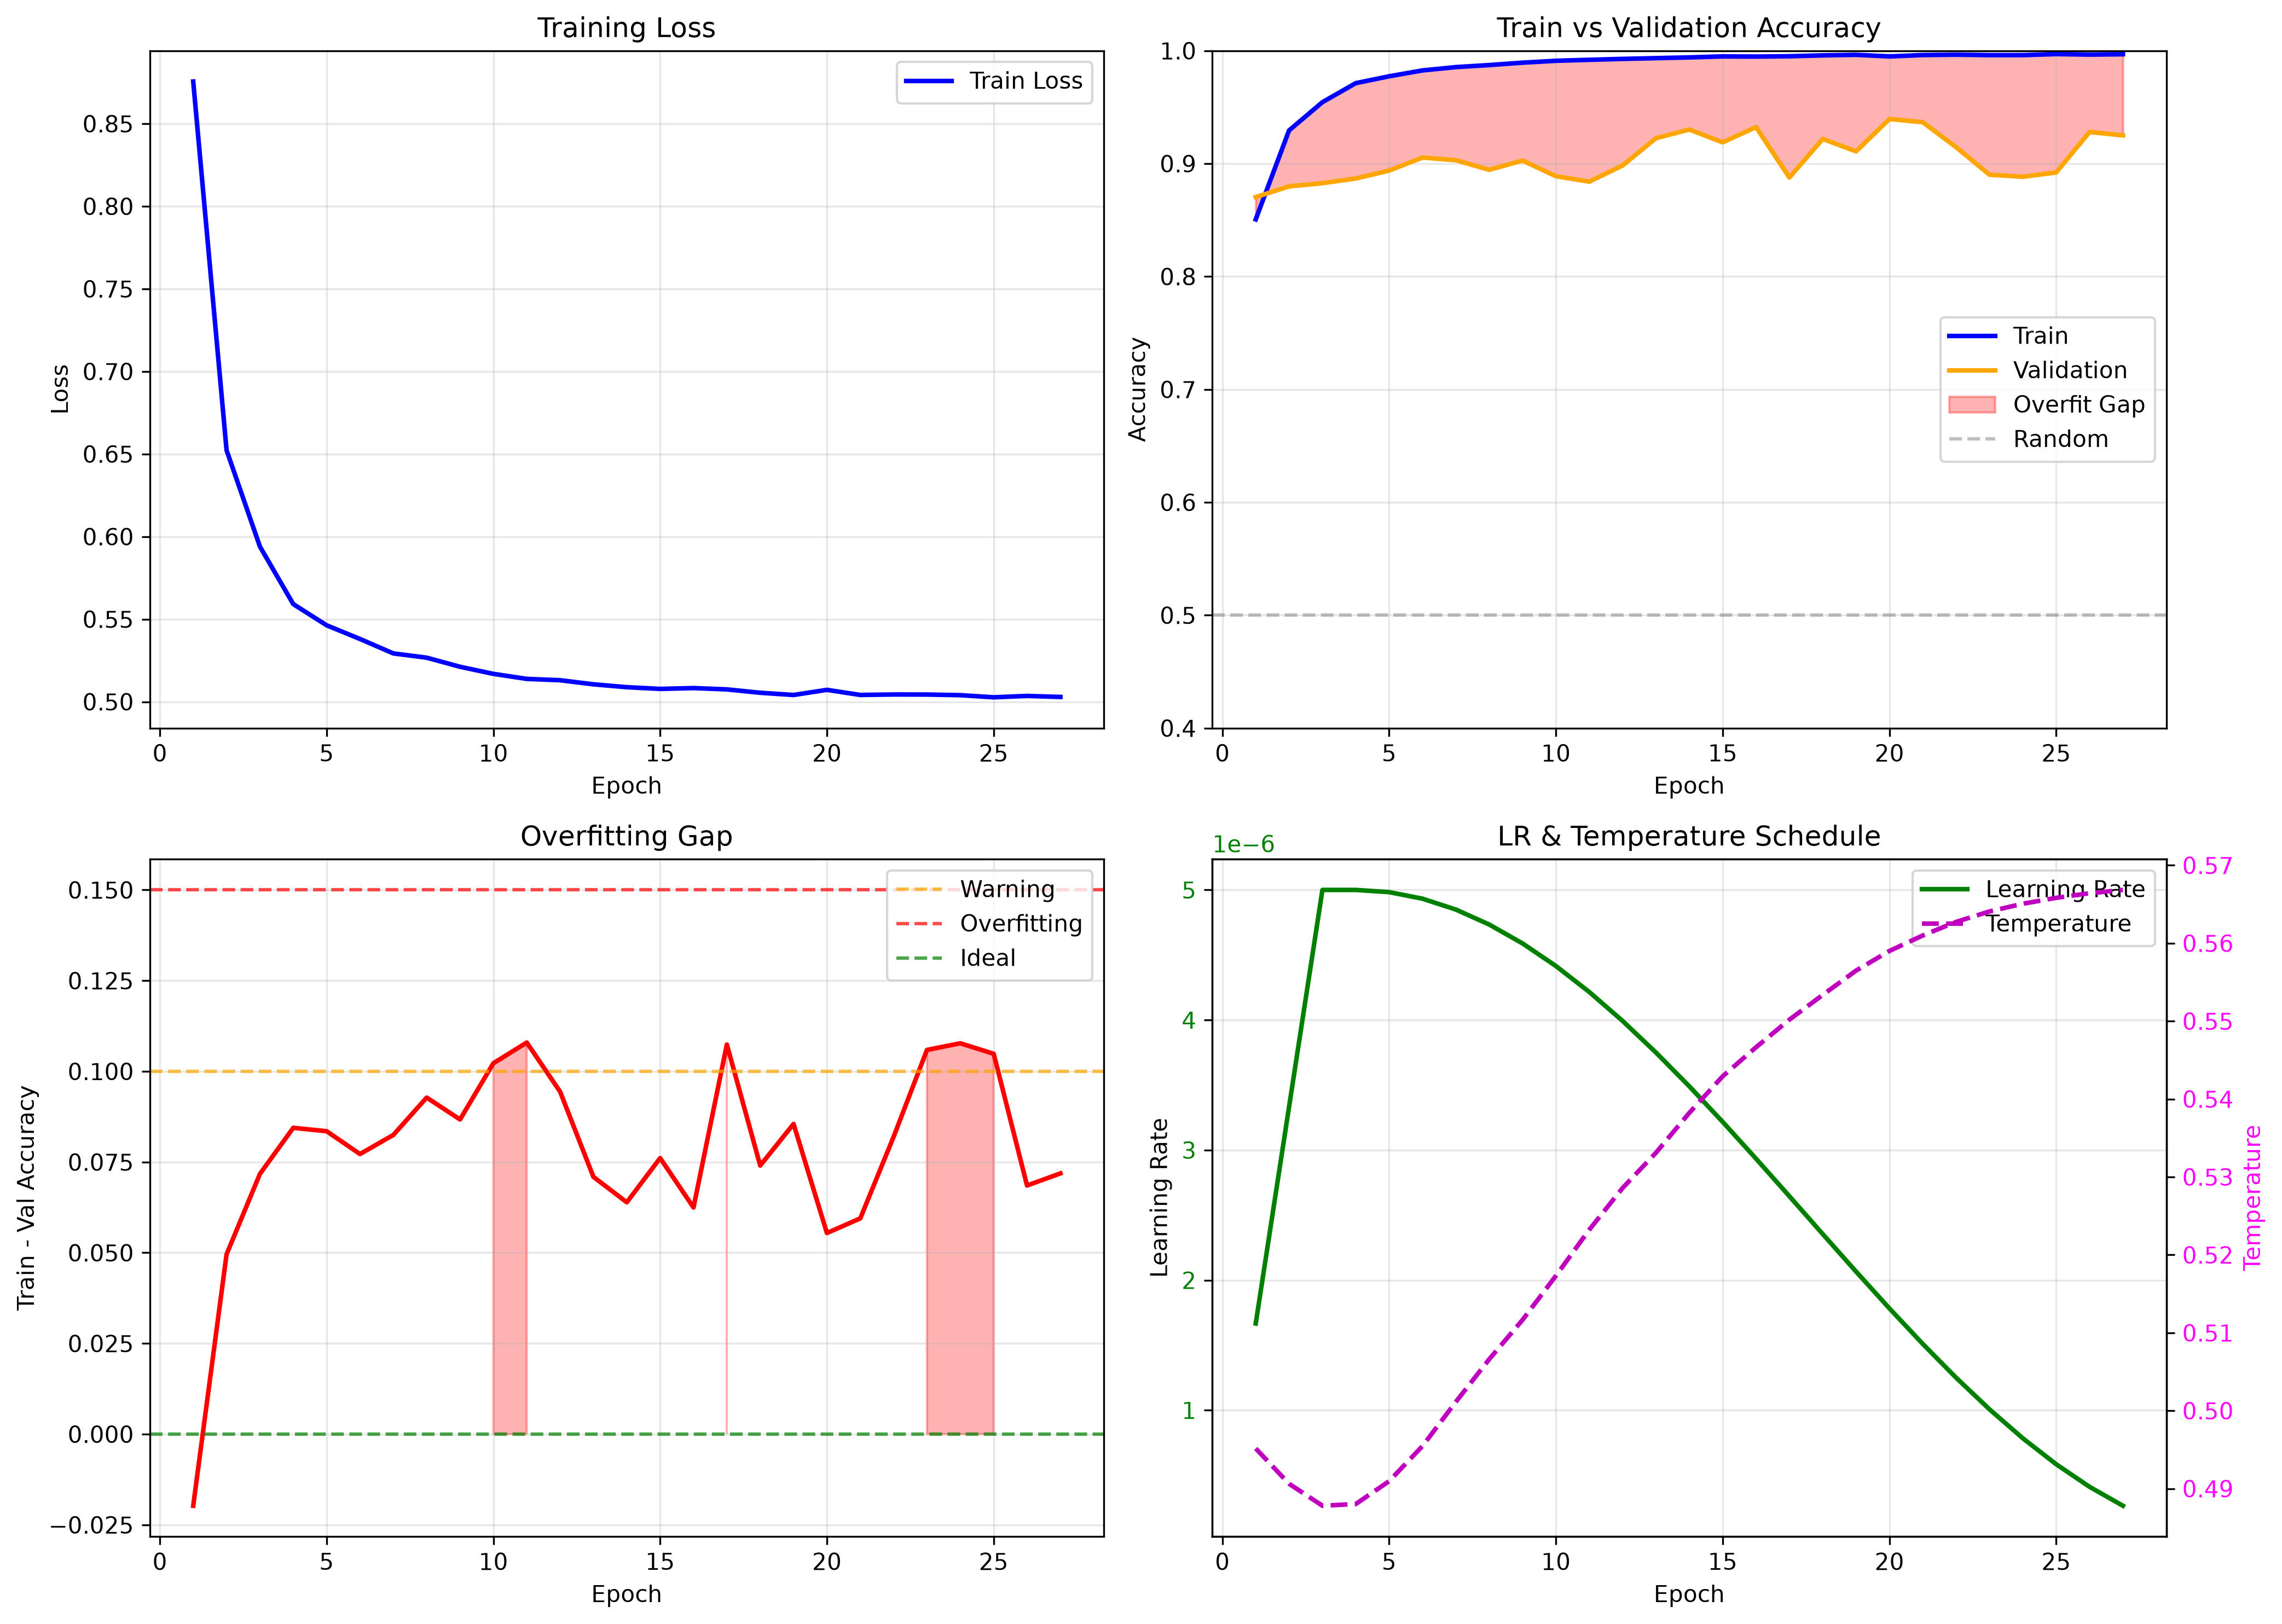

### Confusion matrices on unseen species

`results\run_20260906_200503_seed42\figures\confusion_matrices.png`

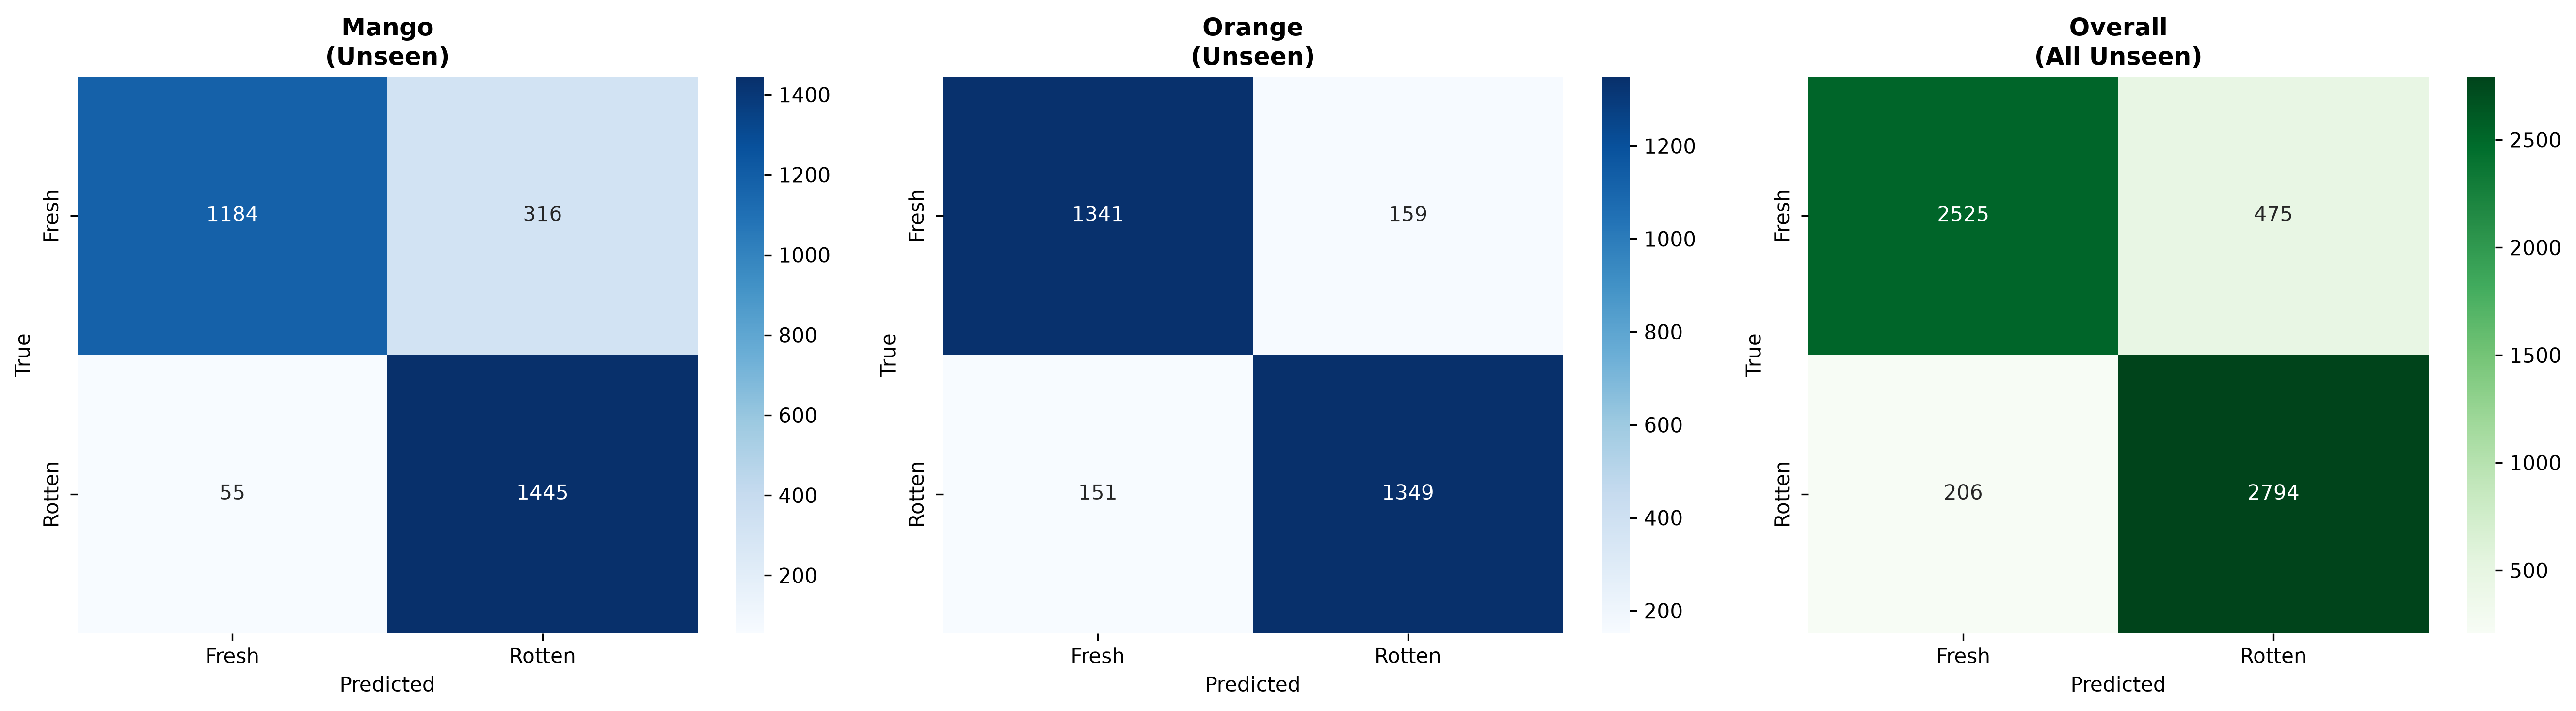

### t-SNE of the learned embedding space

`results\run_20260906_200503_seed42\figures\embedding_tsne.png`

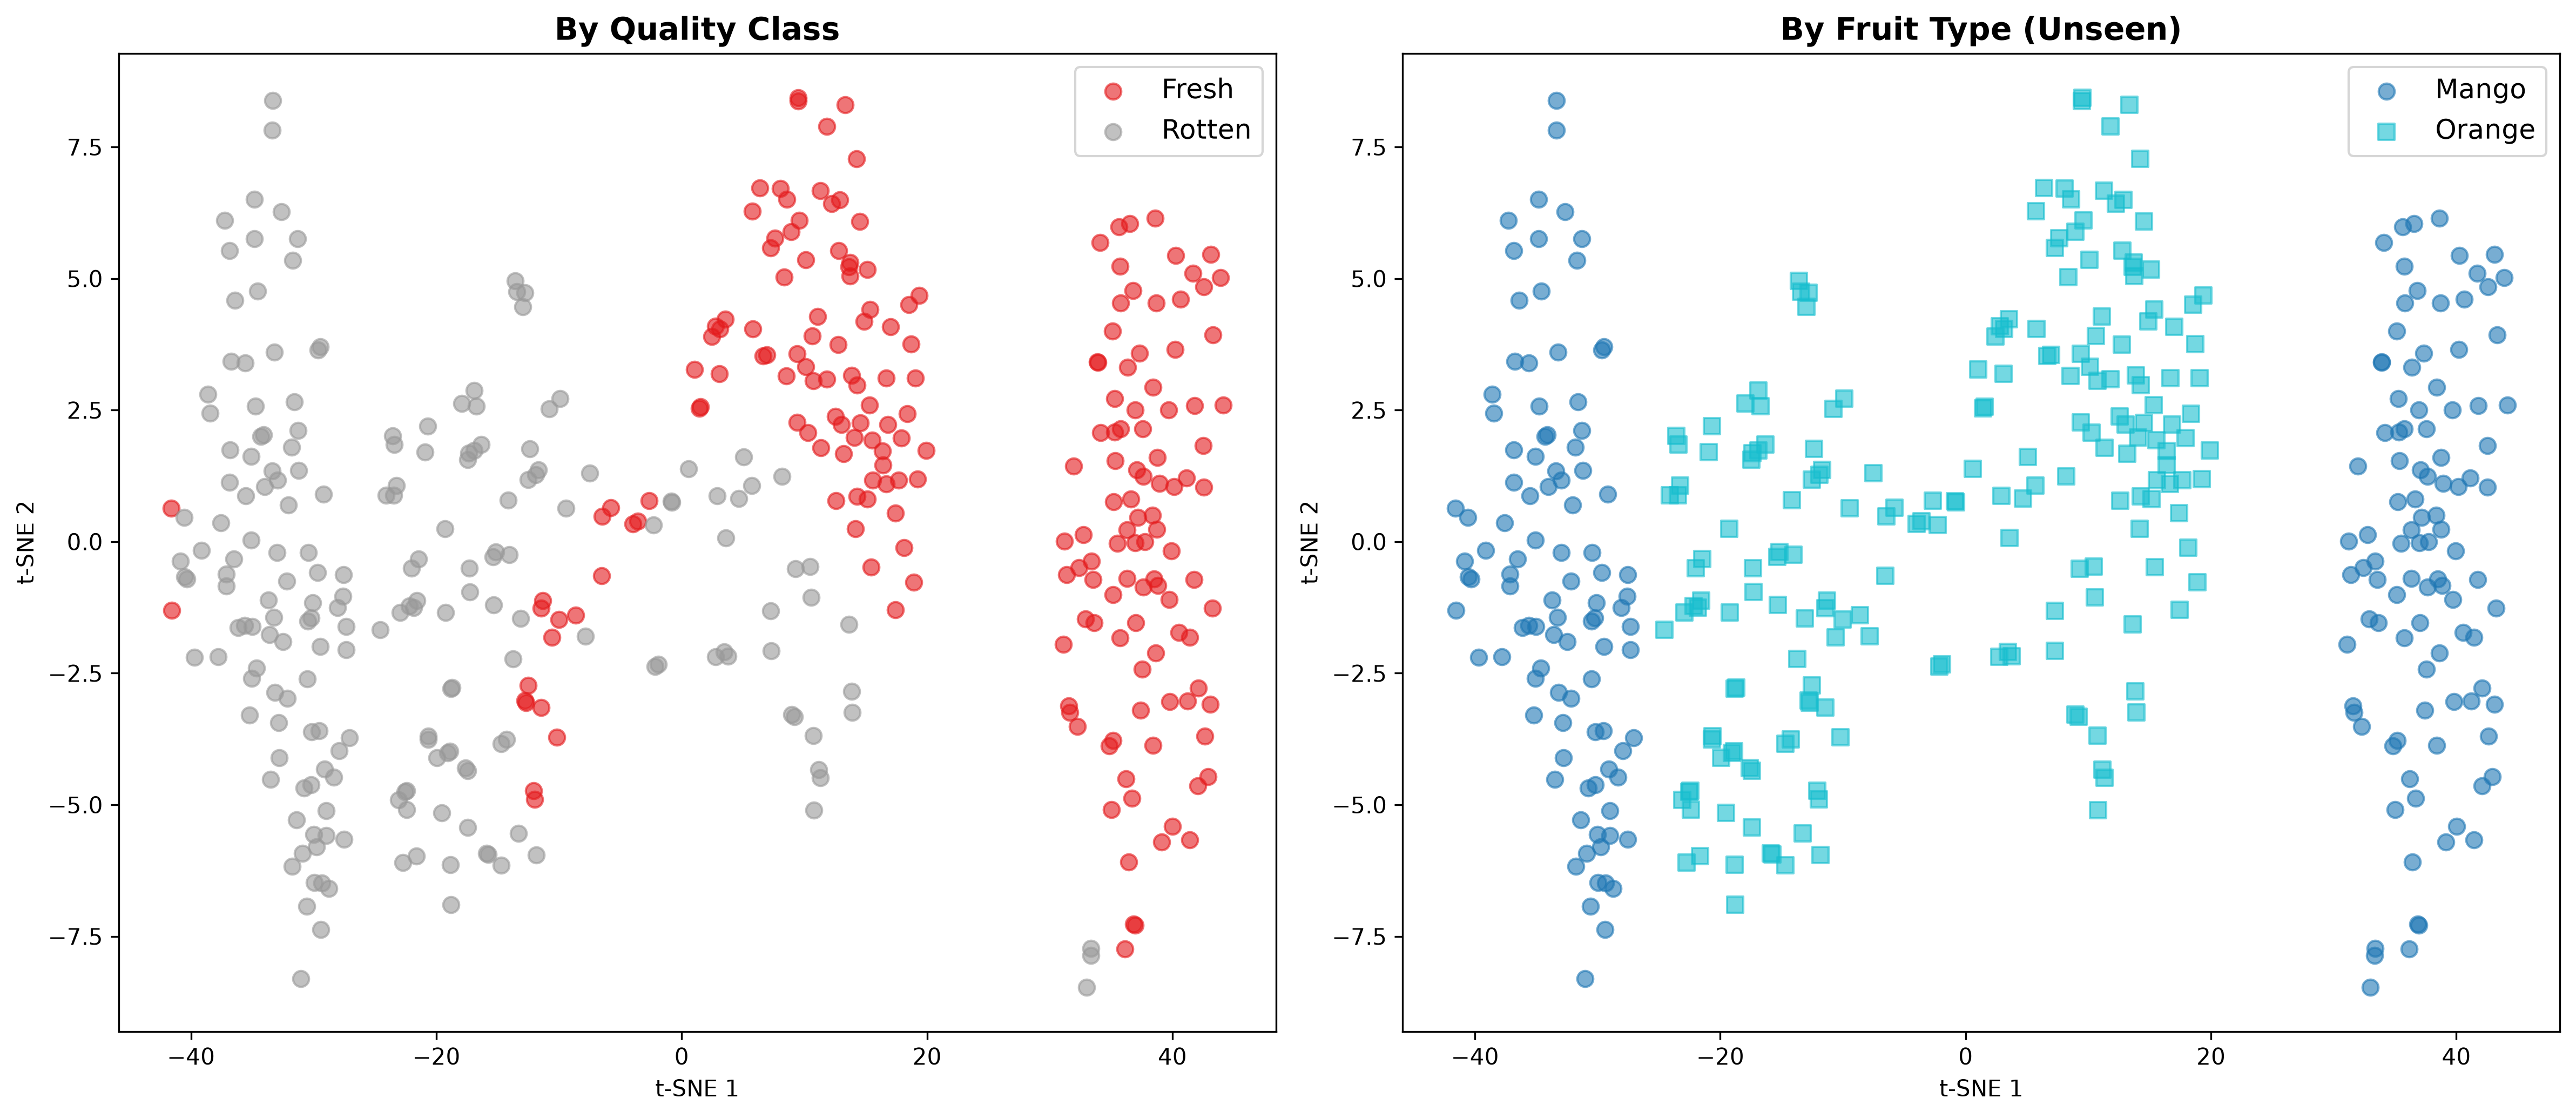

### Accuracy vs. number of support shots

`results\run_20260906_200503_seed42\figures\ablation_nshot.png`

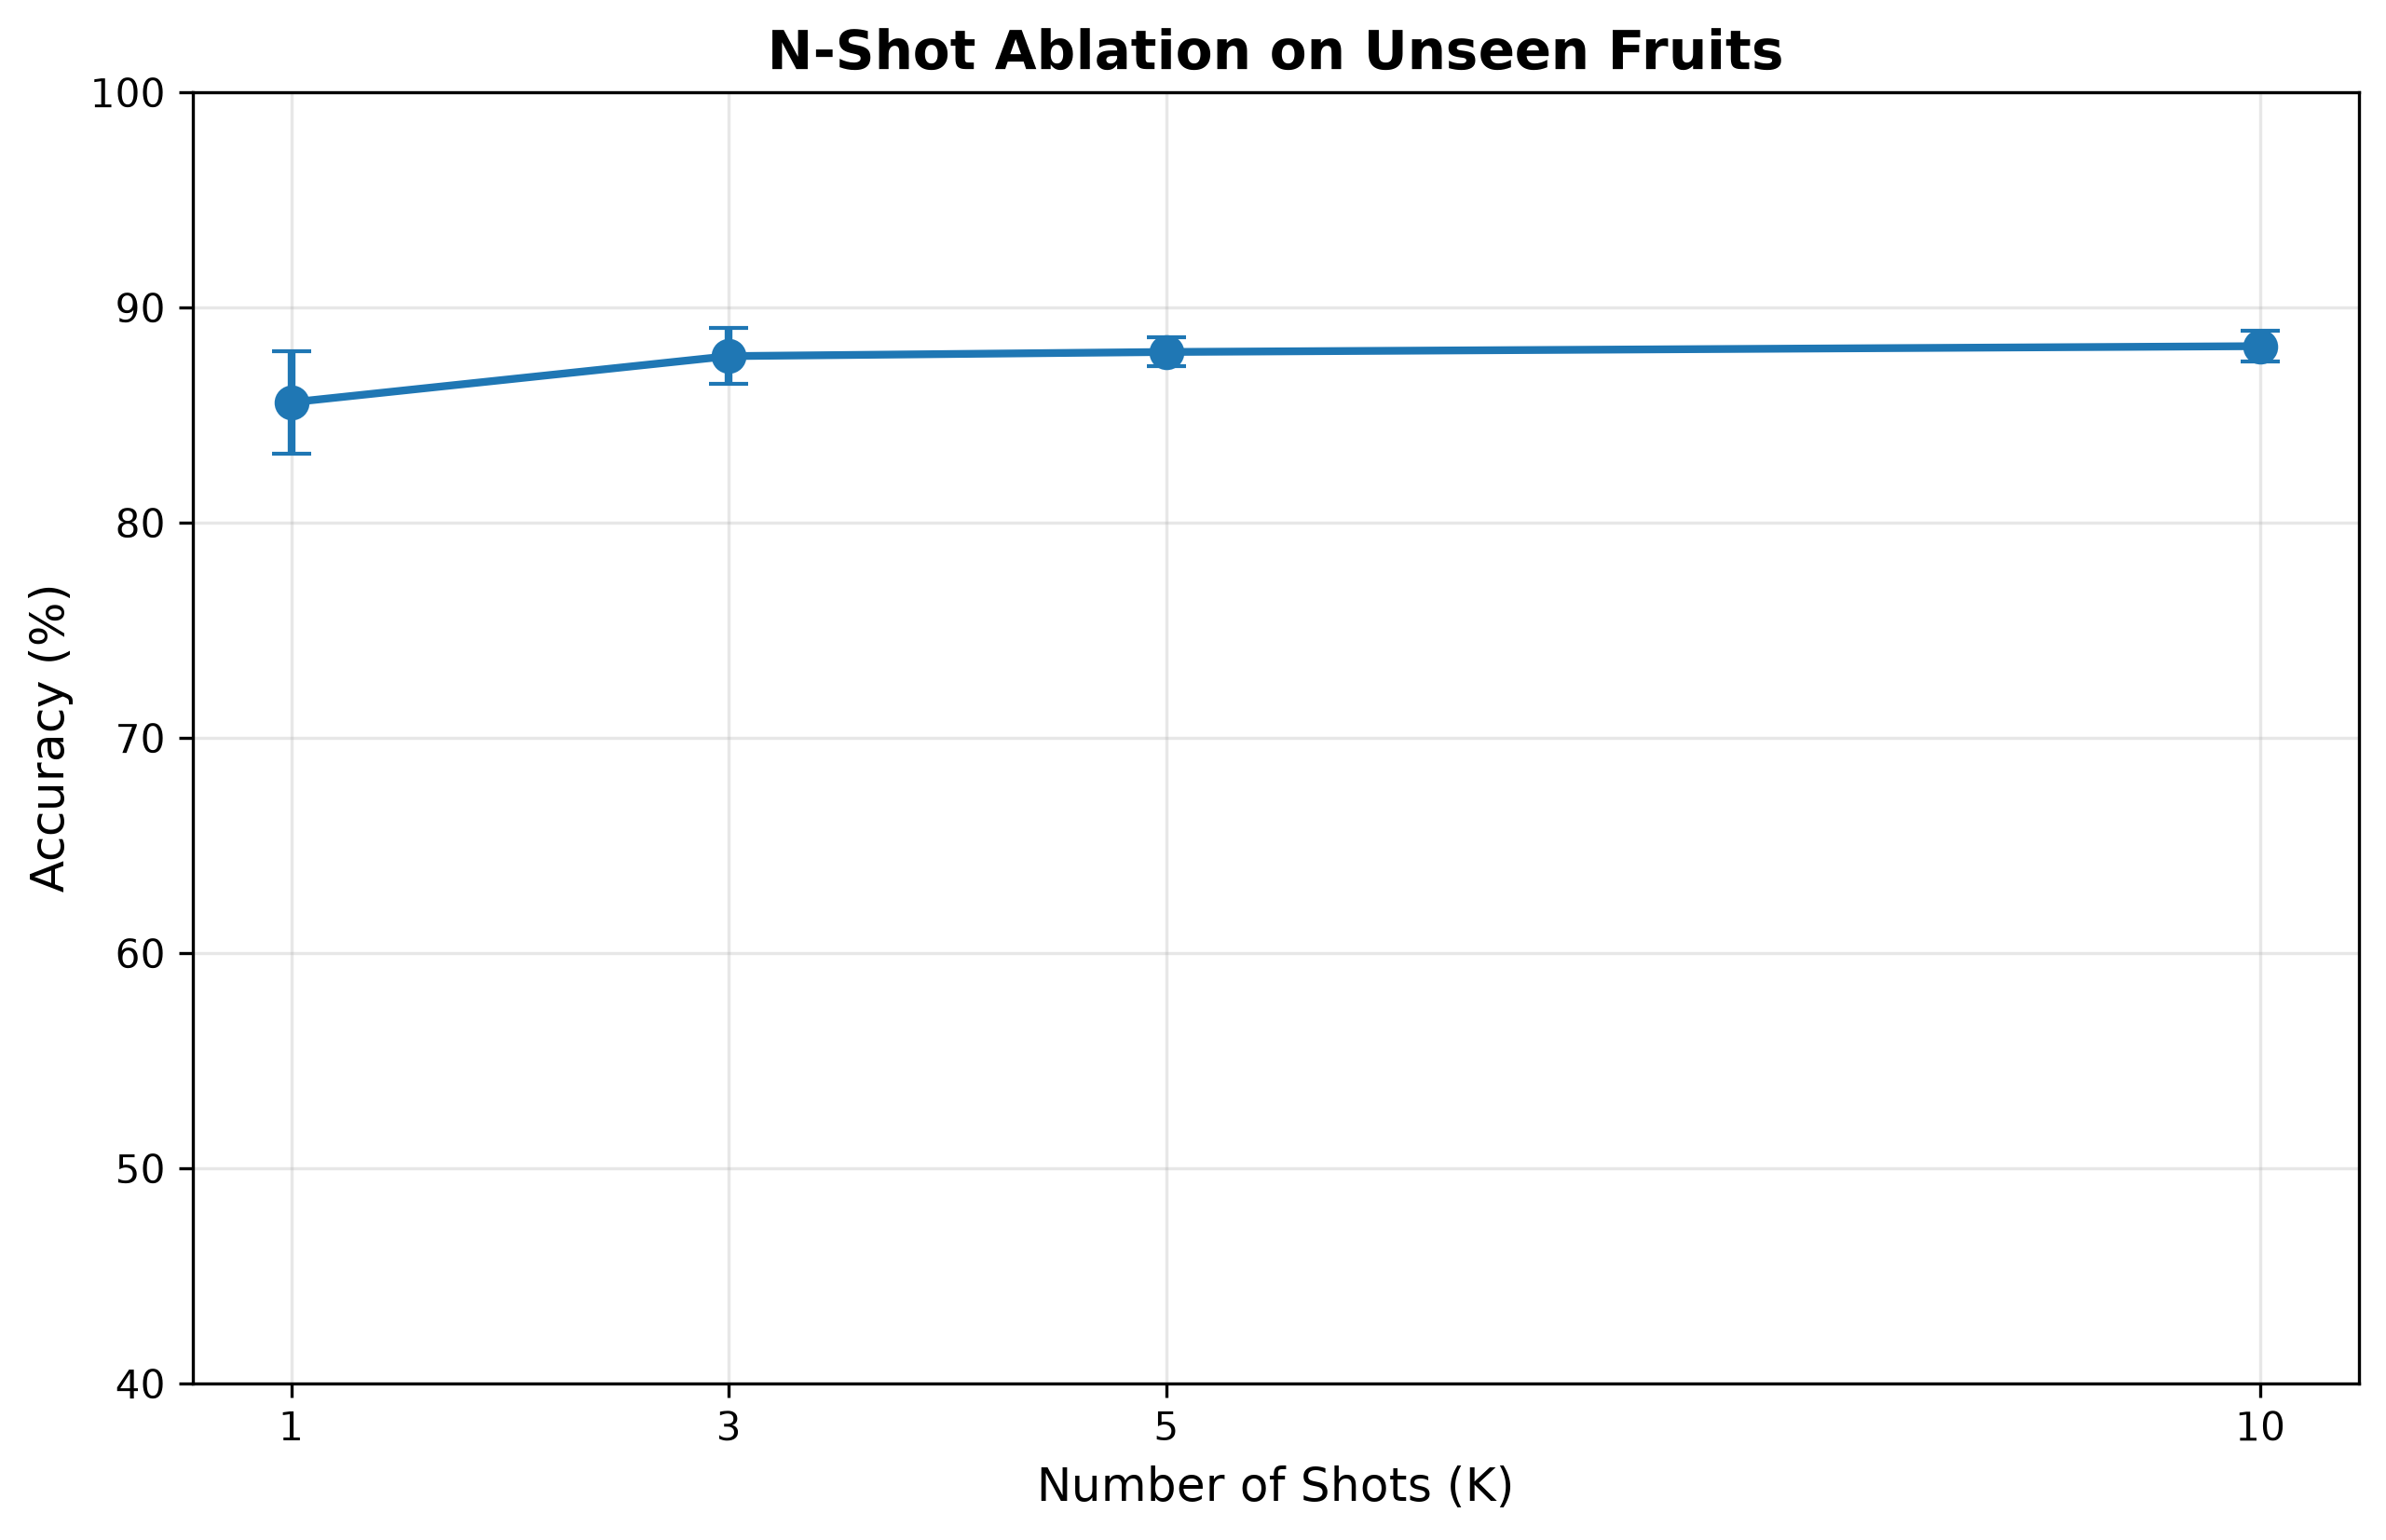

In [11]:
figdir = PRIMARY_DIR / 'figures'
wanted = [
    ('training_curves.png',     'Training and validation curves'),
    ('confusion_matrices.png',  'Confusion matrices on unseen species'),
    ('embedding_tsne.png',      't-SNE of the learned embedding space'),
    ('ablation_nshot.png',      'Accuracy vs. number of support shots'),
]
for fname, caption in wanted:
    p = figdir / fname
    if p.is_file():
        display(Markdown(f'### {caption}\n\n`{p.relative_to(REPO_ROOT)}`'))
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'### {caption}\n\n> `{fname}` not found in {figdir}'))

## 10 - Full traceability index

Every scalar in the primary run, flattened to `key.path = value`. If a number
appears in the thesis, it must appear here. Search this list rather than
re-deriving anything by hand.

In [12]:
def flatten(d, prefix=''):
    rows = []
    for k, v in d.items():
        path = f'{prefix}.{k}' if prefix else str(k)
        if isinstance(v, dict):
            rows.extend(flatten(v, path))
        elif isinstance(v, list):
            if v and all(isinstance(x, (int, float)) for x in v):
                rows.append((f'{path}.n', len(v)))
                rows.append((f'{path}.mean', float(np.mean(v))))
        else:
            rows.append((path, v))
    return rows


flat = pd.DataFrame(flatten(PRIMARY), columns=['metrics.json key', 'value'])
print(f'{len(flat)} scalars in {PRIMARY_DIR.name}/metrics.json')
display(Markdown(f'Also available as `{PRIMARY_DIR.name}/summary.csv`.'))
with pd.option_context('display.max_rows', 500):
    display(flat.set_index('metrics.json key'))

269 scalars in run_20260906_200503_seed42/metrics.json


Also available as `run_20260906_200503_seed42/summary.csv`.

,value
metrics.json key,
seed,42
smoke,False
config.ABLATION_EPISODES,300
config.ABLATION_SHOTS.n,4
config.ABLATION_SHOTS.mean,4.75
config.BACKBONE,resnet18
config.CHECKPOINT_DIR,C:\Users\admin\Desktop\Amr Samir\FewShot-Fruit...
config.CONTRASTIVE_WEIGHT,0.1
config.DATA_ROOT,C:\Users\admin\Desktop\Amr Samir\FruitVision
